In [1]:
import os
os.environ["JAX_PLATFORMS"] = 'cpu'
import jax.numpy as jnp
import jax 
import numpy as np
from utils import (
                  syn_group_id_paths_for_sem_data,
                  sem_ids_with_syn_path,
                  syn_syn_ids_path,
                  collect_data,
                  torch_to_jax,
                  flatten_tokens_features,
                  depths,
                  reduce_list_half_preserve_extremes,
                  remove_syn_group_averages,
                  load_and_subtract_syn_group_averages,
                  remove_sem_group_projections,
                   )
from geometry import normalized_L2_distance
from datapaths import * 
import matplotlib.pyplot as plt
from torch import from_numpy

def cosine_similarity_matrix(X, Y):
    # Normalize rows to unit norm
    X_norm = X / jnp.linalg.norm(X, axis=1, keepdims=True)
    Y_norm = Y / jnp.linalg.norm(Y, axis=1, keepdims=True)
    # Elementwise cosine similarity
    return jnp.sum(X_norm * Y_norm, axis=1)


/home/acevedo/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
min_token_length = 3
n_tokens = min_token_length
n_files = 21
model_name = 'qwen7b'
precision = 32
data_var = 'sem'
avg_tokens = 0

input_path_A = input_paths['english'][model_name]['matching']['0'][data_var]
input_path_B = input_paths['english'][model_name]['matching']['1'][data_var]

In [3]:
all_activations_A = collect_data(input_path_A, 
            min_token_length, 
            n_files,
            model_name,
            avg_tokens,
            )
all_activations_B = collect_data(input_path_B, 
            min_token_length, 
            n_files,
            model_name,
            avg_tokens,
            )

qwen7b dtype: torch.bfloat16


Collect File: 100%|██████████| 21/21 [00:06<00:00,  3.24it/s]


all_hidden_states["layer_0"].shape=torch.Size([2018, 3, 3584])
importing took 0.11971911986668905 m
qwen7b dtype: torch.bfloat16


Collect File: 100%|██████████| 21/21 [00:01<00:00, 15.47it/s]


all_hidden_states["layer_0"].shape=torch.Size([2018, 3, 3584])
importing took 0.03328019380569458 m


In [4]:
def preprocessing(all_activations, 
                  layer, 
                  space_index, 
                  syn_center_flag, 
                  sem_center_flag, 
                  global_center_flag, 
                  removal_method,
                  ):


  syn_syn_indices = jnp.array(np.loadtxt(syn_syn_ids_path,dtype=int),dtype=jnp.int32) # filtering data to ALSO have their syntax group in space B

  # loading data
  _all_activations = all_activations[f"layer_{layer}"]
  act = torch_to_jax(_all_activations[:,-n_tokens:,:],precision)
  act = flatten_tokens_features(act)

  global_center = jnp.mean(act,axis=0)
  # globally centering data [with all samples]
  if global_center_flag:
    act = act - jnp.broadcast_to(global_center,act.shape)
    _global_center = global_center
  else:
    _global_center = None
  
  # keeping semantic data with syn_centers
  sem_ids = jnp.array(np.loadtxt(sem_ids_with_syn_path,dtype=int),dtype=jnp.int32) # filtering data to have their syntax group in space A 
  act = act[sem_ids]

  # loading semantic centers
  semantic_centers_folder = f"/home/acevedo/syn-sem/results/global_centering_0/spaces_AB/similarity_fn_none/precision_32/language_english/data_var_sem/modelA_qwen7b/modelB_qwen7b/match_var_matching/n_files_21/min_token_length_{min_token_length}/semantic_centers/centers_sem/Nbits_0/n_tokens_{n_tokens}/avg_tokens_{avg_tokens}/batch_shuffle_0/layer_A_{layer}/layer_B_{layer}/"
  sem_centers = jnp.array(np.load(semantic_centers_folder+f'semantic_centers_{6}_{0}.npy'), dtype=act.dtype) #(num_sentences,E)

  # loading syntax_centers
  syn_centers_folder = f"/home/acevedo/syn-sem/results/global_centering_0/spaces_AB/similarity_fn_normalized_L2_distance/precision_32/language_english/data_var_syn/modelA_qwen7b/modelB_qwen7b/match_var_matching/n_files_21/min_token_length_{min_token_length}/similarities/centers_syn/Nbits_0/n_tokens_{n_tokens}/avg_tokens_{avg_tokens}/batch_shuffle_0/layer_A_{layer}/layer_B_{layer}/"
  all_syn_centers = jnp.array(np.load(os.path.join(syn_centers_folder, f'syn_centers_{space_index}.npy'))).astype(jnp.float32) #(num_groups,E)
  syn_group_ids_A = jnp.array(np.loadtxt(syn_group_id_paths_for_sem_data['A'],dtype=int), dtype=jnp.int32)
  syn_centers = all_syn_centers[syn_group_ids_A]

  # global_centering centroids...
  if global_center_flag: 
    syn_centers = syn_centers - jnp.broadcast_to(global_center,syn_centers.shape)
    sem_centers = sem_centers - jnp.broadcast_to(global_center,sem_centers.shape)
  
  if space_index == 'A': # for 'A', first syntax_centering, then syntax_filtering
    if syn_center_flag:
      act = load_and_subtract_syn_group_averages(act,syn_group_id_paths_for_sem_data[space_index],syn_centers_folder,syn_center_flag,removal_method,_global_center,space_index)
    if sem_center_flag:
      act = remove_sem_group_projections(act, np.arange(act.shape[0],dtype=jnp.int32), sem_centers)
    act = act[syn_syn_indices]

  if space_index == 'B': # for 'B', first syntax_filtering, then syntax_centering
    if sem_center_flag:
      act = remove_sem_group_projections(act, np.arange(act.shape[0],dtype=jnp.int32), sem_centers)
    act = act[syn_syn_indices]
    if syn_center_flag:
      act = load_and_subtract_syn_group_averages(act,syn_group_id_paths_for_sem_data[space_index],syn_centers_folder,syn_center_flag,removal_method,_global_center,space_index)


  sem_centers = sem_centers[sem_ids][syn_syn_indices]
  syn_centers = syn_centers[syn_syn_indices]
  print(f'{act.shape=}')
  print(f'{syn_centers.shape=}')
  print(f'{global_center.shape=}')

  return act, syn_centers, sem_centers, global_center

In [14]:
layer = 14 
params = [
        (0,0,0,'projection',0),
        ]
for syn_center_flag, sem_center_flag, global_center_flag, removal_method, batch_shuffle_B in params:
  act_A, syn_centers_A, sem_centers_A, global_center_A = preprocessing(
      all_activations_A, 
      layer, 
      space_index='A',
      syn_center_flag=syn_center_flag,
      sem_center_flag=sem_center_flag,
      global_center_flag=global_center_flag,
      removal_method=removal_method,
  )
  act_B, syn_centers_B, sem_centers_B, global_center_B = preprocessing(
      all_activations_B, 
      layer, 
      space_index='B',
      syn_center_flag=syn_center_flag,
      sem_center_flag=sem_center_flag,
      global_center_flag=global_center_flag,
      removal_method=removal_method,
  )

act.shape=(206, 10752)
syn_centers.shape=(206, 10752)
global_center.shape=(10752,)
act.shape=(206, 10752)
syn_centers.shape=(206, 10752)
global_center.shape=(10752,)


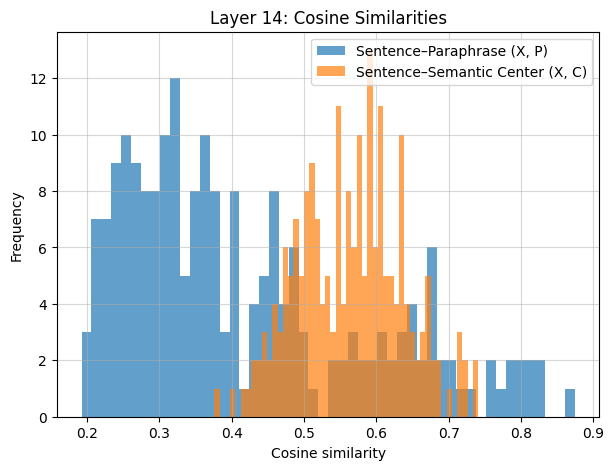

In [15]:
# Cosine similarities between each sentence X and its paraphrase P
cos_sims_XP = cosine_similarity_matrix(act_A, act_B)

# Cosine similarities between each sentence X and its semantic center
cos_sims_XC = cosine_similarity_matrix(act_A, sem_centers_A)

plt.figure(figsize=(7,5))
plt.hist(cos_sims_XP, bins=50, alpha=0.7, label='Sentence–Paraphrase (X, P)')
plt.hist(cos_sims_XC, bins=50, alpha=0.7, label='Sentence–Semantic Center (X, C)')
plt.xlabel('Cosine similarity')
plt.ylabel('Frequency')
plt.title(f'Layer {layer}: Cosine Similarities')
plt.legend()
plt.grid(alpha=0.5)
plt.show()


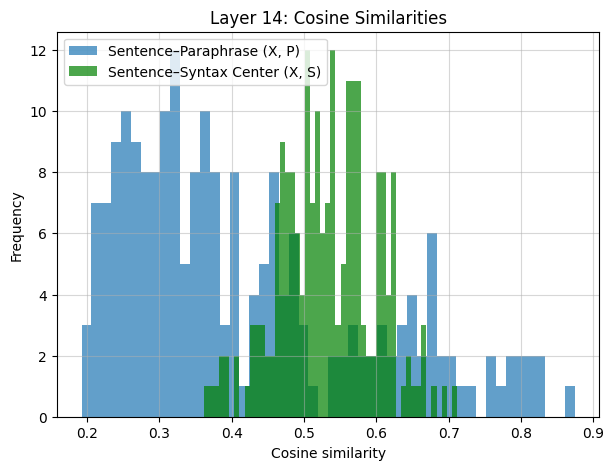

In [16]:
# Cosine similarities
cos_sims_XP = cosine_similarity_matrix(act_A, act_B)
cos_sims_XCsem = cosine_similarity_matrix(act_A, sem_centers_A)
cos_sims_XCsyn = cosine_similarity_matrix(act_A, syn_centers_A)

# Plot
plt.figure(figsize=(7,5))
plt.hist(cos_sims_XP, bins=50, alpha=0.7, label='Sentence–Paraphrase (X, P)')
# plt.hist(cos_sims_XCsem, bins=50, alpha=0.7, label='Sentence–Semantic Center (X, T)')
plt.hist(cos_sims_XCsyn, bins=50, alpha=0.7, label='Sentence–Syntax Center (X, S)',color='green')
plt.xlabel('Cosine similarity')
plt.ylabel('Frequency')
plt.title(f'Layer {layer}: Cosine Similarities')
plt.legend()
plt.grid(alpha=0.5)
plt.show()


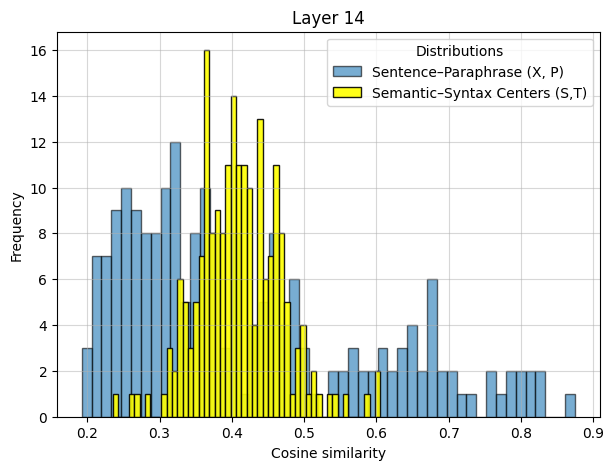

In [18]:
# Cosine similarities between semantic centers and syntax centers
cos_sims_XP = cosine_similarity_matrix(act_A, act_B)
cos_sims_Csem_Csyn = cosine_similarity_matrix(sem_centers_A, syn_centers_A)

plt.figure(figsize=(7,5))
plt.hist(cos_sims_XP, bins=50, alpha=0.6, label='Sentence–Paraphrase (X, P)', edgecolor='black')
plt.hist(cos_sims_Csem_Csyn, bins=50, alpha=0.9, label='Semantic–Syntax Centers (S,T)', color='yellow', edgecolor='black')
plt.xlabel('Cosine similarity')
plt.ylabel('Frequency')
plt.title(f'Layer {layer}')
plt.legend(title='Distributions')
plt.grid(alpha=0.5)
plt.show()

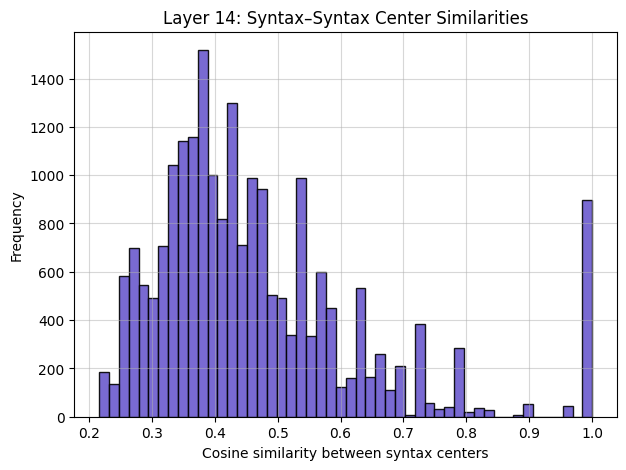

In [19]:
from itertools import combinations

# Compute all unique pairs of syntax centers (without self-pairs)
i, j = jnp.triu_indices(syn_centers_A.shape[0], k=1)
cos_sims_Csyn_Csyn = cosine_similarity_matrix(syn_centers_A[i], syn_centers_A[j])

plt.figure(figsize=(7,5))
plt.hist(cos_sims_Csyn_Csyn, bins=50, color='slateblue', alpha=0.9, edgecolor='black')
plt.xlabel('Cosine similarity between syntax centers')
plt.ylabel('Frequency')
plt.title(f'Layer {layer}: Syntax–Syntax Center Similarities')
plt.grid(alpha=0.5)
plt.show()


: 

: 